COLUMN NAMES:
 Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'month'],
      dtype='str')

FIRST 5 ROWS:
           order_id order_date  ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01 2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01 2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01 2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632 2011-01-01 2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883 2011-01-01 2011-01-08  Standard Class      Joseph Holt   

       segment            state    country  market   region  ... sub_category  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...      Storage   
1     Consumer  

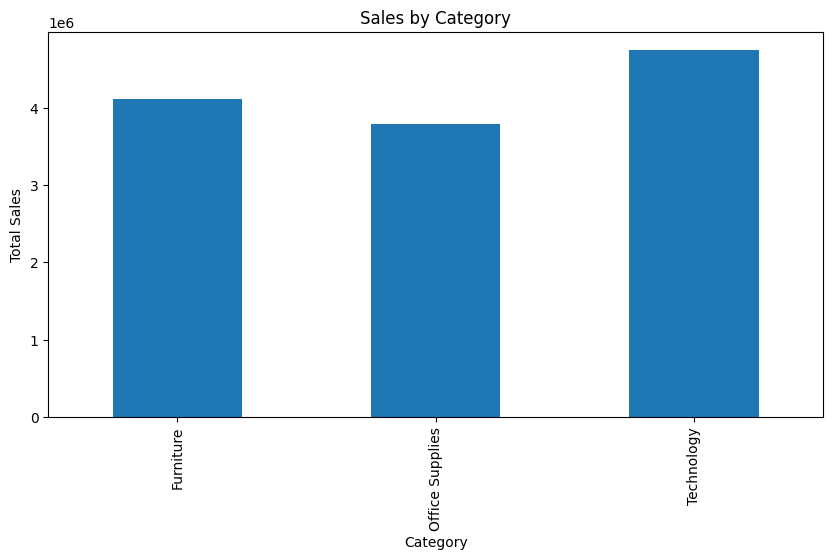

INSIGHT:Technology category usually generates the highest sales.
RECOMMENDATION:Increase stock and marketing for high-performing category like technology.


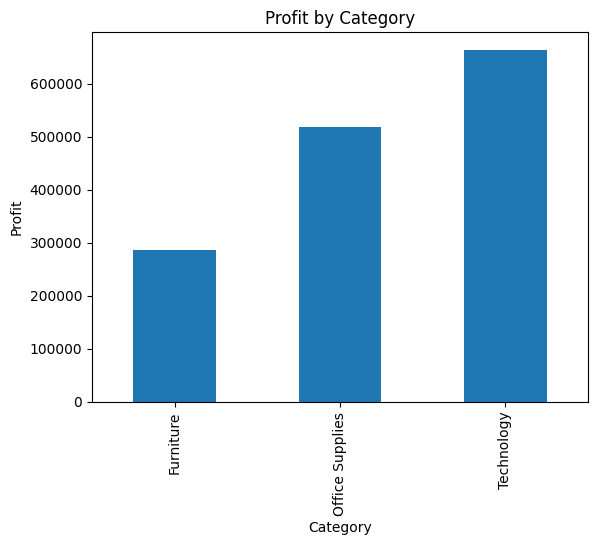

INSIGHTS:Some categories may have high sales but lower profit margins.
RECOMMENDATION:Focus on categories with both high sales and high profitability.


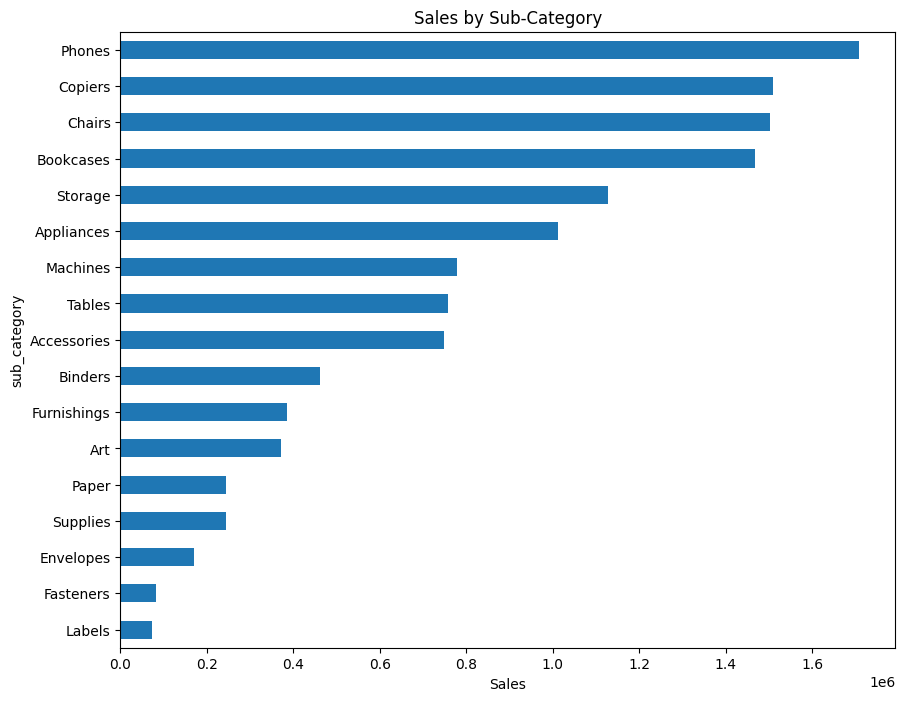

INSIGHTS:Certain sub-categories contribute more revenue than others.
RECOMMENDATION:Increase stock availability for high-selling sub-categories.


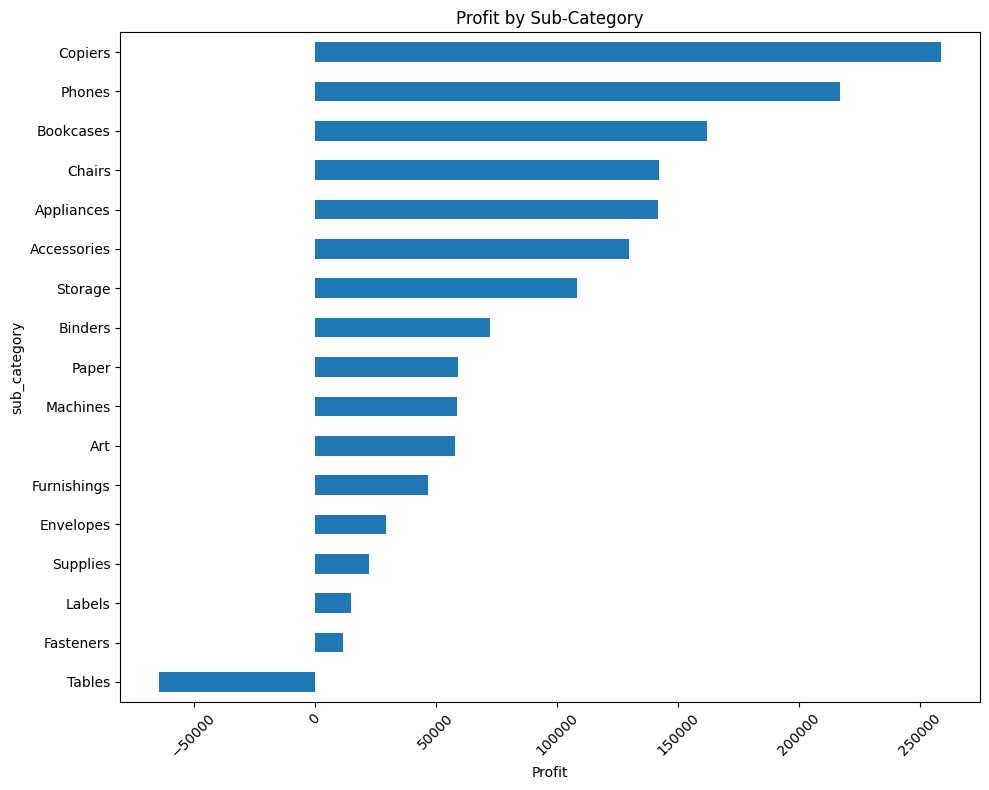

INSIGHTS:Some sub-categories generate losses despite strong sales.
RECOMMENDATION:Review pricing and discount strategy for loss-making products.


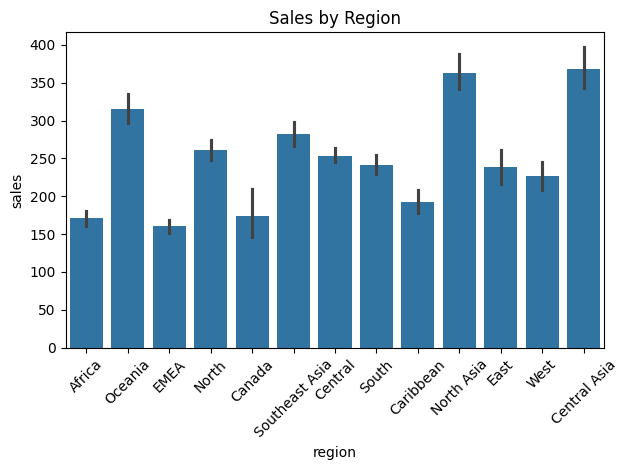

INSIGHTS:Some regions contribute significantly higher revenue.
RECOMMENDATION:Expand business operations in high-performing regions.


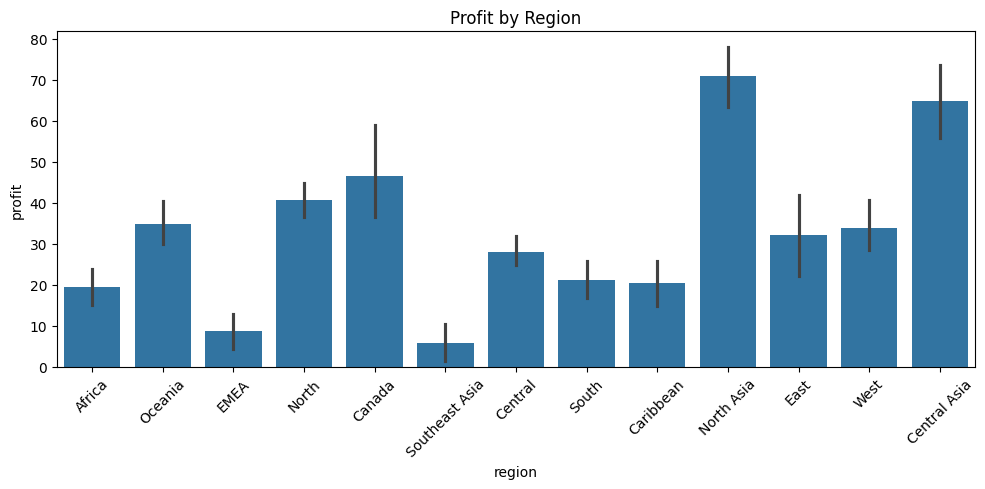

INSIGHTS:Some regions generate sales but lower profits..
RECOMMENDATION:Reduce operational costs in low-profit regions.


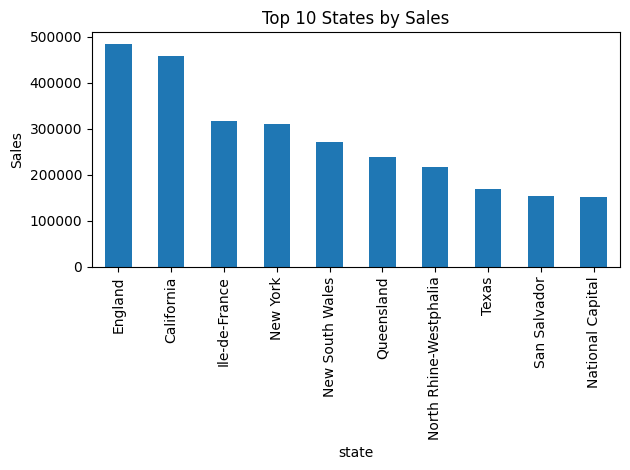

INSIGHTS:A few states dominate overall sales performance.
RECOMMENDATION:Target marketing campaigns in top-performing states.


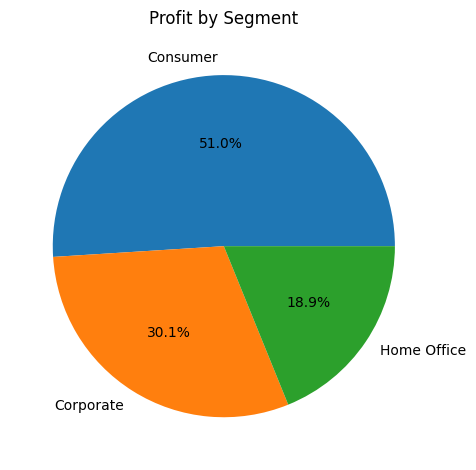

INSIGHTS:Consumer segment contributes major share of profit.
RECOMMENDATION:Focus customer retention strategies on profitable segments.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
df = pd.read_excel("SuperStoreOrders_cleaned.xlsx")

df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month_name()
df['year'] = df['order_date'].dt.year
print("COLUMN NAMES:\n",df.columns)
print("\nFIRST 5 ROWS:\n",df.head())

#TASK 2A — SALES & PROFIT ANALYSIS

#SALES BY CATEGORY
category_sales = df.groupby('category')['sales'].sum()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()
print("INSIGHT:Technology category usually generates the highest sales.")
print("RECOMMENDATION:Increase stock and marketing for high-performing category like technology.")

#PROFIT BY CATEGORY
category_profit = df.groupby('category')['profit'].sum()
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()
print("INSIGHTS:Some categories may have high sales but lower profit margins.")
print("RECOMMENDATION:Focus on categories with both high sales and high profitability.")

#SALES BY SUB-CATEGORY
sub_sales = df.groupby('sub_category')['sales'].sum().sort_values()
sub_sales.plot(kind='barh', figsize=(10,8))
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.show()
print("INSIGHTS:Certain sub-categories contribute more revenue than others.")
print("RECOMMENDATION:Increase stock availability for high-selling sub-categories.")

#PROFIT BY SUB-CATEGORY
sub_profit = df.groupby('sub_category')['profit'].sum().sort_values()
sub_profit.plot(kind='barh', figsize=(10,8))
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("INSIGHTS:Some sub-categories generate losses despite strong sales.")
print("RECOMMENDATION:Review pricing and discount strategy for loss-making products.")

#SALES BY REGION
sns.barplot(x='region', y='sales', data=df)
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("INSIGHTS:Some regions contribute significantly higher revenue.")
print("RECOMMENDATION:Expand business operations in high-performing regions.")

#PROFIT BY REGION
plt.figure(figsize=(10,5))
sns.barplot(x='region', y='profit', data=df)
plt.title("Profit by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("INSIGHTS:Some regions generate sales but lower profits..")
print("RECOMMENDATION:Reduce operational costs in low-profit regions.")

#SALES BY STATE
state_sales = df.groupby('state')['sales'].sum() \
                .sort_values(ascending=False).head(10)
state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
print("INSIGHTS:A few states dominate overall sales performance.")
print("RECOMMENDATION:Target marketing campaigns in top-performing states.")

#PROFIT BY SEGMENT
segment_profit = df.groupby('segment')['profit'].sum()
segment_profit.plot(kind='pie', autopct='%1.1f%%')
plt.title("Profit by Segment")
plt.ylabel("")
plt.tight_layout()
plt.show()
print("INSIGHTS:Consumer segment contributes major share of profit.")
print("RECOMMENDATION:Focus customer retention strategies on profitable segments.")
